## Часть 1. Работа с датасетом

### <font color='#F5DEB3'> 1. Подключение библиотек и первичный анализ данных

*№ варианта (по списку):* **20**.

*Вариант типа поверхности:* **5**.

*Вариант датасета:* **[V1; V3]**.

Проводим работу с независимой выборкой.

In [20]:
import os                          # Взаимодействие с операционной системой
import yaml                        # Чтение и запись данных в формате YAML

import pandas as pd                # Работа с табличными данными (excel)
import numpy as np                 # Работа с многомерными массивами, математические операции
import matplotlib.pyplot as plt    # Построение графиков и визуализация
import seaborn as sns              # Надстройка над matplotlib для красивой визуализации

In [21]:
# Загрузка параметров из yaml-файла
with open('C:/ML_Labs/LB3_ML_Yakushev/config/parameters.yaml', 'r', encoding='utf-8') as config_file:
    config = yaml.safe_load(config_file)

# Меняем рабочую директорию
os.chdir(config['base']['root_project_dir'])

print(config)

{'base': {'random_state': 42, 'root_project_dir': 'C:/ML_Labs/LB3_ML_Yakushev'}, 'robot': {'dist_center': 0.125, 'wheel_angle': 30, 'wheel_radius': 0.04}, 'data': {'dataset_xlsx': 'data/Data_Set_(A+B).xlsx', 'dataset_processed': 'data/processed', 'dataset_test_xlsx': 'data/Data_Set_C.xlsx', 'target_column': 'Type', 'val_size': 0.2, 'type_space': 5}, 'MLP': {'model_params': {'cv_folds': 4}}}


In [22]:
V1 = pd.read_excel('C:/ML_Labs/LB3_ML_Yakushev/data/Data_Set_C.xlsx')
display(V1.info(), V1.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      58 non-null     float64
 1   I2      58 non-null     float64
 2   I3      58 non-null     float64
 3   gx      58 non-null     float64
 4   gy      58 non-null     float64
 5   gz      58 non-null     float64
 6   ax      58 non-null     float64
 7   ay      58 non-null     float64
 8   az      58 non-null     float64
 9   V1real  58 non-null     float64
 10  V2real  58 non-null     float64
 11  V3real  58 non-null     float64
 12  N1      58 non-null     int64  
 13  N2      58 non-null     int64  
 14  N3      58 non-null     int64  
 15  Type    58 non-null     int64  
dtypes: float64(12), int64(4)
memory usage: 7.4 KB


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503329,0.507012,0.530982,0.741187,-1.009176,22.819712,0.001161,-0.003513,-0.003626,176.737116,106.604473,352.529506,2984.465517,1652.103448,6109.741379,3.034483
std,0.328960,0.413925,0.324213,1.578123,2.024289,29.629883,0.015855,0.027644,0.019589,322.519851,371.325096,214.277036,5591.393563,6557.807800,3638.243964,1.426141
min,0.057315,0.000000,0.063348,-1.239375,-5.865625,-3.508824,-0.062402,-0.132782,-0.053271,-291.600000,-358.200000,-3.176471,-5807.000000,-8754.000000,-80.000000,1.000000
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-1925.000000,-4991.750000,3044.000000,2.000000
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,2708.500000,933.500000,5356.500000,3.000000
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,5812.750000,5801.750000,8003.750000,4.000000
max,1.274510,1.523378,1.162393,8.370000,2.211333,88.294667,0.050659,0.089615,0.087982,769.500000,772.200000,783.000000,14384.000000,14083.000000,14168.000000,5.000000


In [23]:
display(V1.duplicated().sum())

np.int64(0)

### <font color='#F5DEB3'> 2. Анализ данных

In [24]:
def compute_V2_V3(V1, config):
    l = config['robot']['dist_center']
    r = config['robot']['wheel_radius']
    theta_degree = config['robot']['wheel_angle']

    theta = np.radians(theta_degree)         # угол установки колёс
    alpha = 0
    n = V1.shape[0]                # массив углов поворота робота
    
    # Знаки скоростей вращения для коррекции знаков токов
    omega_arr = V1[['V1real', 'V2real', 'V3real']].values
    sign_omega = np.sign(omega_arr)


    # Создаём массивы для матриц (n,3,3)
    M_vel = np.zeros((n, 3, 3))
    M_curr = np.zeros((n, 3, 3))

    # ----- Матрица скоростей -----
    M_vel[:,0,0] = - (2/3) * np.cos(alpha - theta)
    M_vel[:,0,1] =   (2/3) * np.sin(alpha)
    M_vel[:,0,2] =   (2/3) * np.cos(alpha + theta)
    
    M_vel[:,1,0] = - (2/3) * np.sin(alpha - theta)
    M_vel[:,1,1] = - (2/3) * np.cos(alpha)
    M_vel[:,1,2] =   (2/3) * np.sin(alpha + theta)
    
    M_vel[:,2,0] = 1/(3*l)
    M_vel[:,2,1] = 1/(3*l)
    M_vel[:,2,2] = 1/(3*l)

    M_curr[:,0,:] = M_vel[:,0,:]
    M_curr[:,1,:] = M_vel[:,1,:]
    M_curr[:,2,0] = 1/3
    M_curr[:,2,1] = 1/3
    M_curr[:,2,2] = 1/3


    # ----- Вычисление Vx, Vy, Ω -----
    V = np.einsum('ijk,ik->ij', M_vel, omega_arr) * r   # (n,3)

    # ----- Вычисление Ix, Iy, Iφ -----
    I_arr = V1[['I1', 'I2', 'I3']].values
    I_signed = I_arr * sign_omega
    I_vec = np.einsum('ijk,ik->ij', M_curr, I_signed)   # (n,3)

    # ----- IΣ (суммарная трудоёмкость) -----
    I_sum = np.sum(np.abs(I_vec), axis=1)

    # ----- Вычисление V3 (относительные параметры) -----
    eps = 1e-6
    Tx = V[:,0] / (I_vec[:,0] + eps)
    Ty = V[:,1] / (I_vec[:,1] + eps)
    Tphi = V[:,2] / (I_vec[:,2] + eps)
    Tz = V1['gz'].values / (I_vec[:,2] + eps)

    # Формируем DataFrame V2
    V2 = pd.DataFrame({
        'Vx': V[:,0],
        'Vy': V[:,1],
        'Ω': V[:,2],
        'Ix': I_vec[:,0],
        'Iy': I_vec[:,1],
        'Iφ': I_vec[:,2],
        'IΣ': I_sum
    }, index=V1.index)

    # Формируем DataFrame V3
    V3 = pd.DataFrame({
        'Tx': Tx,
        'Ty': Ty,
        'Tφ': Tphi,
        'Tz': Tz
    }, index=V1.index)

    return V2, V3

def prepare_target(V, target_col, type_space):
    V_pr = V.copy()
    
    # Бинарное преобразование
    V_pr[target_col] = (V_pr[target_col] == type_space).astype(int)
    
    other_cols = [col for col in V_pr.columns if col != target_col]
    V_pr = V_pr[other_cols + [target_col]]
    
    return V_pr

In [25]:
V2, V3 = compute_V2_V3(V1, config)
display(V2.head(), V3.head())

,Vx,Vy,Ω,Ix,Iy,Iφ,IΣ
0,11.810549,0.042353,0.338824,1.280097,-0.023127,-0.023127,1.326350
1,-0.183394,12.430588,0.847059,-0.010450,1.083962,-0.051785,1.146197
2,13.241019,13.404706,2.541176,0.747159,0.780292,-0.094520,1.621970
3,0.287787,0.055385,52.283077,-0.043273,-0.109139,0.350427,0.502839
4,-0.249415,0.048000,113.280000,-0.005922,-0.007977,0.345869,0.359767


,Tx,Ty,Tφ,Tz
0,9.226285,-1.831437,-14.651493,-8.012535
1,17.551697,11.467723,-16.357552,35.270971
2,17.721798,17.179075,-26.885429,32.088257
3,-6.650680,-0.507474,149.197718,46.323556
4,42.126882,-6.017920,327.522196,99.524959


In [26]:
processed_path = os.path.join(config['data']['dataset_processed'], 'Data_Set_AB_processed.xlsx')

V13_AB = pd.read_excel(processed_path)

In [27]:
V13 = pd.concat([V1, V3], axis=1)

V13.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      58 non-null     float64
 1   I2      58 non-null     float64
 2   I3      58 non-null     float64
 3   gx      58 non-null     float64
 4   gy      58 non-null     float64
 5   gz      58 non-null     float64
 6   ax      58 non-null     float64
 7   ay      58 non-null     float64
 8   az      58 non-null     float64
 9   V1real  58 non-null     float64
 10  V2real  58 non-null     float64
 11  V3real  58 non-null     float64
 12  N1      58 non-null     int64  
 13  N2      58 non-null     int64  
 14  N3      58 non-null     int64  
 15  Type    58 non-null     int64  
 16  Tx      58 non-null     float64
 17  Ty      58 non-null     float64
 18  Tφ      58 non-null     float64
 19  Tz      58 non-null     float64
dtypes: float64(16), int64(4)
memory usage: 9.2 KB


In [28]:
display(V13.describe()) 

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type,Tx,Ty,Tφ,Tz
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503329,0.507012,0.530982,0.741187,-1.009176,22.819712,0.001161,-0.003513,-0.003626,176.737116,106.604473,352.529506,2984.465517,1652.103448,6109.741379,3.034483,6.096889,9.484758,170.384154,65.708885
std,0.328960,0.413925,0.324213,1.578123,2.024289,29.629883,0.015855,0.027644,0.019589,322.519851,371.325096,214.277036,5591.393563,6557.807800,3638.243964,1.426141,22.548461,18.800919,273.832268,114.891897
min,0.057315,0.000000,0.063348,-1.239375,-5.865625,-3.508824,-0.062402,-0.132782,-0.053271,-291.600000,-358.200000,-3.176471,-5807.000000,-8754.000000,-80.000000,1.000000,-84.325527,-10.530215,-159.627995,-234.409752
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-1925.000000,-4991.750000,3044.000000,2.000000,-3.749489,-2.861153,-26.860668,-10.015560
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,2708.500000,933.500000,5356.500000,3.000000,3.521580,0.624522,30.767836,34.987533
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,5812.750000,5801.750000,8003.750000,4.000000,18.505180,18.116951,310.755055,112.442277
max,1.274510,1.523378,1.162393,8.370000,2.211333,88.294667,0.050659,0.089615,0.087982,769.500000,772.200000,783.000000,14384.000000,14083.000000,14168.000000,5.000000,63.164679,80.290886,889.293852,436.251567


In [29]:
display(V13.duplicated().sum(), V13.isnull().sum())

np.int64(0)

I1        0
I2        0
I3        0
gx        0
gy        0
gz        0
ax        0
ay        0
az        0
V1real    0
V2real    0
V3real    0
N1        0
N2        0
N3        0
Type      0
Tx        0
Ty        0
Tφ        0
Tz        0
dtype: int64

In [30]:
# Копируем исходные данные
V13_clean = V13.copy()

# Выбираем числовые столбцы (кроме Type, если он целевой)
num_cols = V13_clean.select_dtypes(include=np.number).columns.tolist()
if 'Type' in num_cols:
    num_cols.remove('Type')

# Кэпируем по 1-му и 99-му перцентилю
for col in num_cols:
    lower = V13_clean[col].quantile(0.01)
    upper = V13_clean[col].quantile(0.99)
    V13_clean[col] = V13_clean[col].clip(lower, upper)

display(V13_clean.describe())

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type,Tx,Ty,Tφ,Tz
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503945,0.506539,0.531279,0.734887,-1.008022,22.822795,0.001332,-0.003181,-0.004147,176.708371,106.532609,353.313639,2979.728621,1667.306724,6115.480690,3.034483,6.409496,9.410240,169.690494,65.487738
std,0.326441,0.412757,0.323600,1.530747,2.009366,29.622094,0.014222,0.022420,0.017231,322.230443,371.129612,212.509588,5556.250215,6504.252705,3592.767048,1.426141,20.760580,18.371366,271.575018,108.561241
min,0.120559,0.000000,0.083753,-1.076874,-5.620881,-3.237571,-0.043830,-0.083880,-0.051869,-287.496000,-356.981625,50.960118,-5393.180000,-7352.370000,804.070000,1.000000,-60.290440,-8.660636,-152.681178,-174.829218
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-1925.000000,-4991.750000,3044.000000,2.000000,-3.749489,-2.861153,-26.860668,-10.015560
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,2708.500000,933.500000,5356.500000,3.000000,3.521580,0.624522,30.767836,34.987533
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,5812.750000,5801.750000,8003.750000,4.000000,18.505180,18.116951,310.755055,112.442277
max,1.246998,1.495925,1.159241,7.842117,2.033517,88.202232,0.042008,0.059919,0.056349,763.728750,766.813500,774.343125,13695.440000,13563.160000,13616.810000,5.000000,57.260812,74.099220,842.114739,363.844507


### <font color='#F5DEB3'> 3. Работа над итоговым датасетом по варианту (V1+V3 для 5-го типа поверхности)

In [31]:
columns_to_drop = ['N1', 'N2', 'N3']
V13_filtered = V13_clean.drop(columns=columns_to_drop)

In [32]:
type_space = config['data']['type_space']
target_col = config['data']['target_column']

# перемещение столбца "Type" на последний столбец
V13 = prepare_target(V13_filtered, target_col, type_space)

display(V13.info(), V13.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      58 non-null     float64
 1   I2      58 non-null     float64
 2   I3      58 non-null     float64
 3   gx      58 non-null     float64
 4   gy      58 non-null     float64
 5   gz      58 non-null     float64
 6   ax      58 non-null     float64
 7   ay      58 non-null     float64
 8   az      58 non-null     float64
 9   V1real  58 non-null     float64
 10  V2real  58 non-null     float64
 11  V3real  58 non-null     float64
 12  Tx      58 non-null     float64
 13  Ty      58 non-null     float64
 14  Tφ      58 non-null     float64
 15  Tz      58 non-null     float64
 16  Type    58 non-null     int64  
dtypes: float64(16), int64(1)
memory usage: 7.8 KB


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,Tx,Ty,Tφ,Tz,Type
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503945,0.506539,0.531279,0.734887,-1.008022,22.822795,0.001332,-0.003181,-0.004147,176.708371,106.532609,353.313639,6.409496,9.410240,169.690494,65.487738,0.206897
std,0.326441,0.412757,0.323600,1.530747,2.009366,29.622094,0.014222,0.022420,0.017231,322.230443,371.129612,212.509588,20.760580,18.371366,271.575018,108.561241,0.408619
min,0.120559,0.000000,0.083753,-1.076874,-5.620881,-3.237571,-0.043830,-0.083880,-0.051869,-287.496000,-356.981625,50.960118,-60.290440,-8.660636,-152.681178,-174.829218,0.000000
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-3.749489,-2.861153,-26.860668,-10.015560,0.000000
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,3.521580,0.624522,30.767836,34.987533,0.000000
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,18.505180,18.116951,310.755055,112.442277,0.000000
max,1.246998,1.495925,1.159241,7.842117,2.033517,88.202232,0.042008,0.059919,0.056349,763.728750,766.813500,774.343125,57.260812,74.099220,842.114739,363.844507,1.000000


## Часть 2. Работа с MLPClassifier

### <font color='#F5DEB3'> Подготовка данных и модели

In [33]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yaml

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE, ADASYN

import ast

In [34]:
target_col = [config['data']['target_column']]
feature_cols = [col for col in V13.columns if col not in target_col]

data_x = np.array(V13.drop(target_col, axis=1))
data_y = np.array(V13[target_col]).ravel()

data_x_AB = np.array(V13_AB.drop(target_col, axis=1))
data_y_AB = np.array(V13_AB[target_col]).ravel()

In [74]:
scaler = MinMaxScaler()
adasyn = ADASYN(random_state=42)
smote = SMOTE(random_state=42)

data_x_scaled_AB = scaler.fit_transform(data_x_AB)
data_x_scaled_С = scaler.fit_transform(data_x)
X_adasyn, Y_adasyn = adasyn.fit_resample(data_x_scaled_AB, data_y_AB)
X_smote, Y_smote = smote.fit_resample(data_x_scaled_AB, data_y_AB)

#### <font color='#F5DEB3'> Тестирование на неизвестном наборе данных

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

def plot_train_test_predictions(
    data_x_AB, data_y_AB,   # обучающие данные
    data_x, data_y,         # проверочные данные
    parameters,             # dict с гиперпараметрами MLPClassifier
    n_show=None,
    output_path=None,
    dpi=600
):
    # 1. Обучение
    mlp = MLPClassifier(**parameters, random_state=42)
    mlp.fit(data_x_AB, data_y_AB)

    # 2. Предсказание на проверочной выборке
    y_pred = mlp.predict(data_x)
    acc = accuracy_score(data_y, y_pred)
    f1 = f1_score(data_y, y_pred, average='binary')  # для 0/1

    # Вывод метрик перед графиком
    print(f"Accuracy = {acc:.4f}")
    print(f"F1-score = {f1:.4f}")

    # 3. Сколько показывать
    if n_show is None:
        n_show = len(data_y)
    else:
        n_show = min(n_show, len(data_y))

    indices = np.arange(n_show)

    # 4. График
    plt.figure(figsize=(14, 6))
    plt.plot(indices, data_y[:n_show], label='Реальные метки (0/1)',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred[:n_show], label='Предсказанный класс (0/1)',
             color='red', linewidth=2, alpha=0.8)
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс (0 или 1)')
    plt.title(f'Сравнение реальных и предсказанных классов на проверочной выборке')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=dpi, bbox_inches='tight')

    plt.show()

Accuracy = 0.8621
F1-score = 0.7143


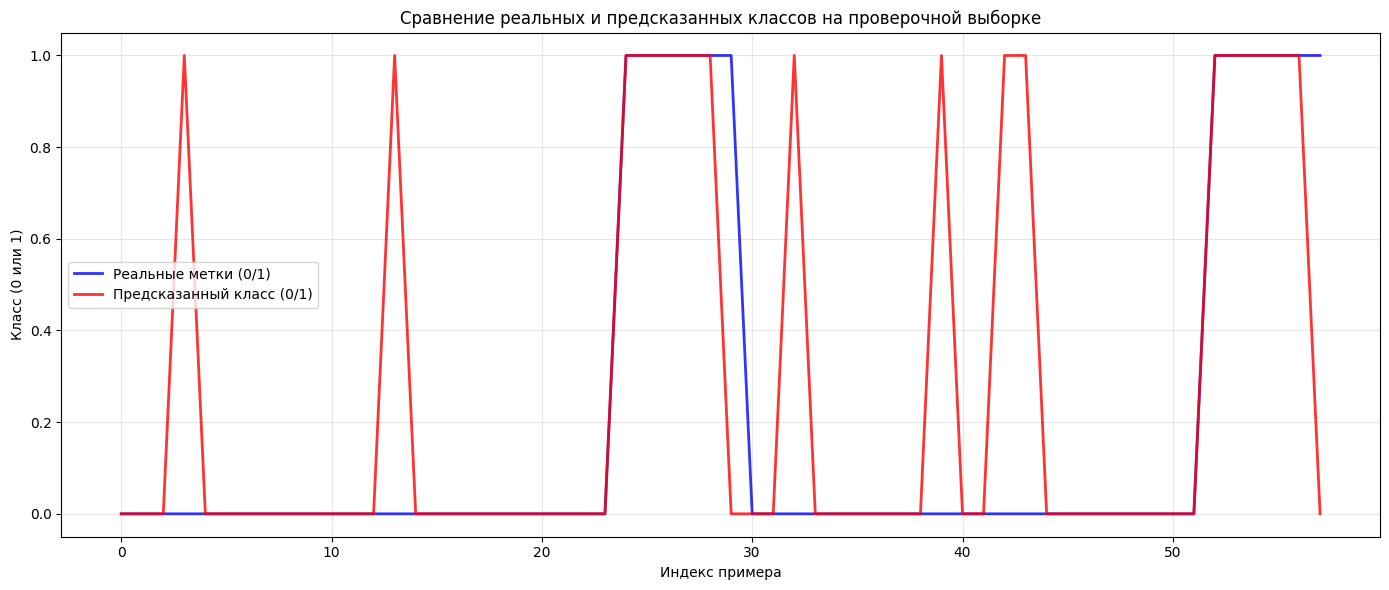

In [95]:
best_params = {
    'hidden_layer_sizes': (100, 50, 50), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 5000
    }

plot_train_test_predictions(
    X_adasyn, Y_adasyn,   
    data_x_scaled_С, data_y,   
    best_params,
    output_path='results/test_histogram.png'
)

Accuracy = 0.8621
F1-score = 0.6923


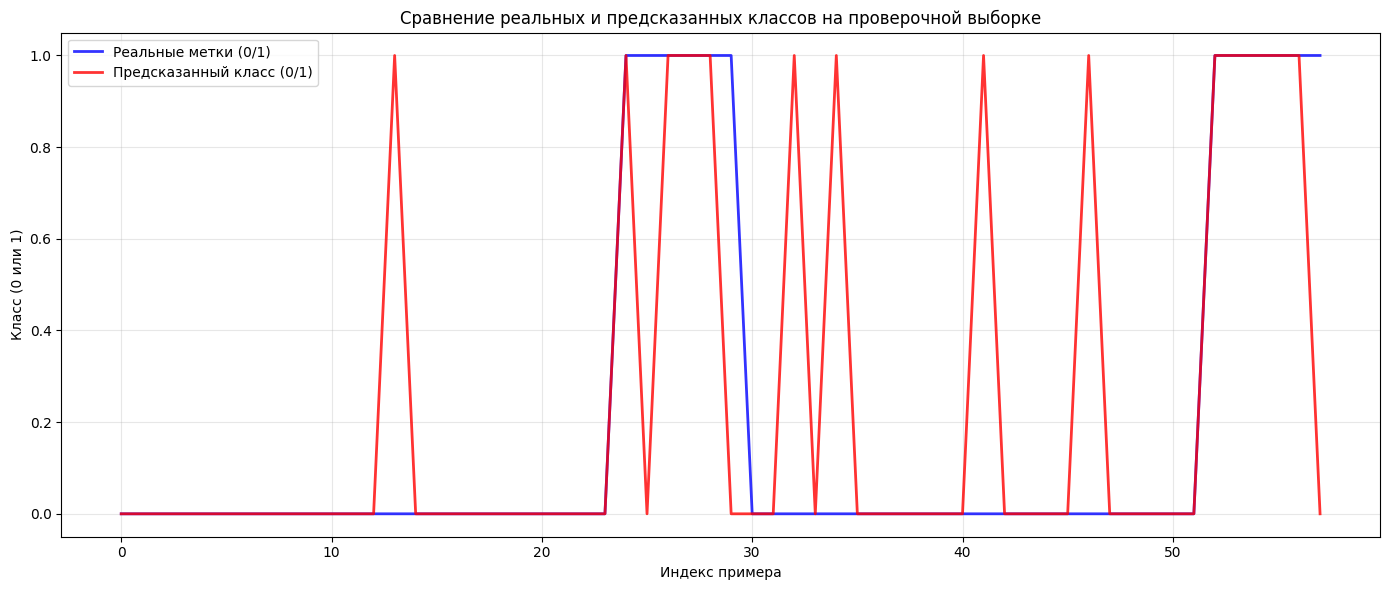

In [111]:
best_params = {
    'hidden_layer_sizes': (75, 49, 33), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 5000,
    'alpha': 0.0017027151146454267
    }

plot_train_test_predictions(
    X_adasyn, Y_adasyn,   
    data_x_scaled_С, data_y,   
    best_params,
    output_path='results/test_histogram.png'
)

Accuracy = 0.8448
F1-score = 0.5714


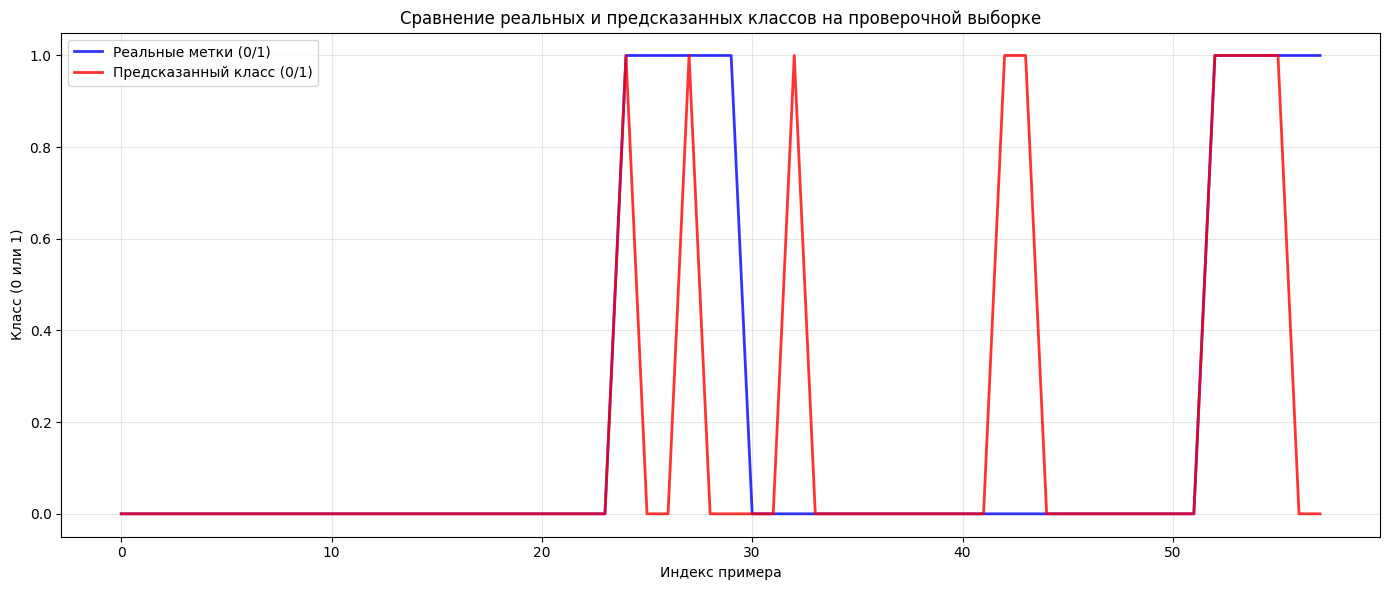

In [85]:
best_params = {
    'hidden_layer_sizes': (66, 47, 24), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 4500,
    'alpha': 0.027544569077163284
    }

plot_train_test_predictions(
    X_smote, Y_smote,   
    data_x_scaled_С, data_y,   
    best_params,
    output_path='results/test_histogram.png'
)